# HW 1.3: Neural POS Tagger

In this exercise, you are going to build a set of deep learning models on part-of-speech (POS) tagging using Pytorch.

To complete this exercise, you will need to build deep learning models for POS tagging in Thai using NECTEC's ORCHID corpus. You will build one model for each of the following type:

- Neural POS Tagging (without pretrained weights)
- Neural POS Tagging with CRF (with and without pretrained weights)

Pretrained word embeddding are already given for you to use (albeit, a very bad one).

We also provide the code for data cleaning, preprocessing and some starter code for pytorch in this notebook but feel free to modify those parts to suit your needs. Feel free to use additional libraries (e.g. scikit-learn) as long as you have a model for each type mentioned above.

### Don't forget to change hardware accelrator to GPU in runtime on Google Colab ###

## 1. Setup and Preprocessing

We use POS data from [ORCHID corpus](https://www.researchgate.net/profile/Virach-Sornlertlamvanich/publication/2630580_Building_a_Thai_part-of-speech_tagged_corpus_ORCHID/links/02e7e514db19a98619000000/Building-a-Thai-part-of-speech-tagged-corpus-ORCHID.pdf), which is a POS corpus for Thai language.
A method used to read the corpus into a list of sentences with (word, POS) pairs have been implemented already. The example usage has shown below.
We also create a word vector for unknown word by random.

In [3]:
from data.orchid_corpus import get_sentences
import numpy as np
import numpy.random
np.random.seed(42)

In [4]:
yunk_emb = np.random.randn(32)
train_data = get_sentences('train')
test_data = get_sentences('test')
print(train_data[0])

[('การ', 'FIXN'), ('ประชุม', 'VACT'), ('ทาง', 'NCMN'), ('วิชาการ', 'NCMN'), ('<space>', 'PUNC'), ('ครั้ง', 'CFQC'), ('ที่ 1', 'DONM')]


Next, we load pretrained weight embedding using pickle. The pretrained weight is a dictionary which map a word to its embedding.

In [5]:
import pickle
fp = open(r'resources\basic_ff_embedding.pt', 'rb')
embeddings = pickle.load(fp)
fp.close()

In [6]:
embeddings

{'พุทธเจ้าพระองค์': array([-0.01917224, -0.00415204, -0.02412283, -0.04142096,  0.04691369,
         0.03376952, -0.00270034, -0.04676848,  0.03299177,  0.03790374,
         0.0432213 , -0.01537431, -0.02517369, -0.04052844, -0.01157572,
         0.00185845, -0.00034374,  0.03099574, -0.00553056,  0.03075998,
        -0.02743803, -0.03812069, -0.02771009, -0.00890391, -0.03464903,
        -0.03346384, -0.04095409,  0.03574741,  0.04473687,  0.0170097 ,
        -0.00490531,  0.01063981], dtype=float32),
 'จุ๊บุ': array([ 0.02896592,  0.02110482,  0.03715003,  0.02296479, -0.03441135,
         0.03496312,  0.03625641, -0.02355627, -0.03617386,  0.01206947,
         0.02429886, -0.02565069, -0.02642049, -0.03778682, -0.00951525,
        -0.0446926 , -0.02631601,  0.04875654,  0.04526813,  0.0079442 ,
         0.0340622 ,  0.00625456,  0.01675535,  0.01817935, -0.03839616,
        -0.04811118,  0.03423071,  0.015117  ,  0.00746933,  0.02313724,
         0.01740095,  0.02209598], dtype=floa

The given code below generates an indexed dataset(each word is represented by a number) for training and testing data. The index 0 is reserved for padding to help with variable length sequence. (Additionally, You can read more about padding here https://suzyahyah.github.io/pytorch/2019/07/01/DataLoader-Pad-Pack-Sequence.html)

## 2. Prepare Data

In [7]:
word_to_idx ={}
idx_to_word ={}
label_to_idx = {}
for sentence in train_data:
    for word,pos in sentence:
        if word not in word_to_idx:
            word_to_idx[word] = len(word_to_idx)+1
            idx_to_word[word_to_idx[word]] = word
        if pos not in label_to_idx:
            label_to_idx[pos] = len(label_to_idx)+1
word_to_idx['UNK'] = len(word_to_idx)

n_classes = len(label_to_idx.keys())+1

In [8]:
word_to_idx

{'การ': 1,
 'ประชุม': 2,
 'ทาง': 3,
 'วิชาการ': 4,
 '<space>': 5,
 'ครั้ง': 6,
 'ที่ 1': 7,
 'โครงการวิจัยและพัฒนา': 8,
 'อิเล็กทรอนิกส์': 9,
 'และ': 10,
 'คอมพิวเตอร์': 11,
 'ปีงบประมาณ': 12,
 '2531': 13,
 'เล่ม': 14,
 '1': 15,
 'ศูนย์เทคโนโลยีอิเล็กทรอนิกส์และคอมพิวเตอร์แห่งชาติ': 16,
 'กระทรวงวิทยาศาสตร์ เทคโนโลยีและการพลังงาน': 17,
 'วัน': 18,
 'ที่ 15': 19,
 '<minus>': 20,
 '16': 21,
 'สิงหาคม': 22,
 '2532': 23,
 'ห้องประชุม': 24,
 'ชั้น': 25,
 '4': 26,
 'สาร': 27,
 'ฯพณฯ': 28,
 'รัฐมนตรีว่าการ': 29,
 'ประเทศไทย': 30,
 'ได้': 31,
 'มี': 32,
 'ปรับเปลี่ยน': 33,
 'โครงสร้าง': 34,
 'ใน': 35,
 'พัฒนา': 36,
 'เศรษฐกิจ': 37,
 'ของ': 38,
 'ประเทศ': 39,
 'จาก': 40,
 'เกษตรกรรม': 41,
 'ไปสู่': 42,
 'ความ': 43,
 'เป็น': 44,
 'ประเทศอุตสาหกรรม': 45,
 'มาก': 46,
 'ยิ่งขึ้น': 47,
 'ดำเนินการ': 48,
 'เพื่อให้': 49,
 'บรรลุ': 50,
 'วัตถุประสงค์': 51,
 'ดังกล่าว': 52,
 'จะ': 53,
 'ต้อง': 54,
 'อาศัย': 55,
 'ปัจจัยพื้นฐาน': 56,
 'หลาย': 57,
 'ประการ': 58,
 'ตัวเร่ง': 59,
 'ฐาน': 60,
 'เช่น': 61,
 

In [9]:
idx_to_word

{1: 'การ',
 2: 'ประชุม',
 3: 'ทาง',
 4: 'วิชาการ',
 5: '<space>',
 6: 'ครั้ง',
 7: 'ที่ 1',
 8: 'โครงการวิจัยและพัฒนา',
 9: 'อิเล็กทรอนิกส์',
 10: 'และ',
 11: 'คอมพิวเตอร์',
 12: 'ปีงบประมาณ',
 13: '2531',
 14: 'เล่ม',
 15: '1',
 16: 'ศูนย์เทคโนโลยีอิเล็กทรอนิกส์และคอมพิวเตอร์แห่งชาติ',
 17: 'กระทรวงวิทยาศาสตร์ เทคโนโลยีและการพลังงาน',
 18: 'วัน',
 19: 'ที่ 15',
 20: '<minus>',
 21: '16',
 22: 'สิงหาคม',
 23: '2532',
 24: 'ห้องประชุม',
 25: 'ชั้น',
 26: '4',
 27: 'สาร',
 28: 'ฯพณฯ',
 29: 'รัฐมนตรีว่าการ',
 30: 'ประเทศไทย',
 31: 'ได้',
 32: 'มี',
 33: 'ปรับเปลี่ยน',
 34: 'โครงสร้าง',
 35: 'ใน',
 36: 'พัฒนา',
 37: 'เศรษฐกิจ',
 38: 'ของ',
 39: 'ประเทศ',
 40: 'จาก',
 41: 'เกษตรกรรม',
 42: 'ไปสู่',
 43: 'ความ',
 44: 'เป็น',
 45: 'ประเทศอุตสาหกรรม',
 46: 'มาก',
 47: 'ยิ่งขึ้น',
 48: 'ดำเนินการ',
 49: 'เพื่อให้',
 50: 'บรรลุ',
 51: 'วัตถุประสงค์',
 52: 'ดังกล่าว',
 53: 'จะ',
 54: 'ต้อง',
 55: 'อาศัย',
 56: 'ปัจจัยพื้นฐาน',
 57: 'หลาย',
 58: 'ประการ',
 59: 'ตัวเร่ง',
 60: 'ฐาน',
 61: 'เช่น',
 

In [10]:
label_to_idx

{'FIXN': 1,
 'VACT': 2,
 'NCMN': 3,
 'PUNC': 4,
 'CFQC': 5,
 'DONM': 6,
 'JCRG': 7,
 'NCNM': 8,
 'CNIT': 9,
 'NPRP': 10,
 'NTTL': 11,
 'XVAM': 12,
 'VSTA': 13,
 'RPRE': 14,
 'ADVN': 15,
 'JSBR': 16,
 'DDAC': 17,
 'XVBM': 18,
 'XVMM': 19,
 'DIBQ': 20,
 'PREL': 21,
 'VATT': 22,
 'XVAE': 23,
 'DCNM': 24,
 'CMTR': 25,
 'FIXV': 26,
 'PPRS': 27,
 'XVBB': 28,
 'DIAC': 29,
 'PDMN': 30,
 'DDAN': 31,
 'CLTV': 32,
 'ADVP': 33,
 'NLBL': 34,
 'ADVI': 35,
 'CMTR@PUNC': 36,
 'JCMP': 37,
 'ADVS': 38,
 'DDBQ': 39,
 'NEG': 40,
 'PNTR': 41,
 'EITT': 42,
 'DDAQ': 43,
 'NONM': 44,
 'EAFF': 45,
 'DIAQ': 46,
 'CVBL': 47}

This section is tweaked a little from the demo, word2features will return word index instead of features, and sent2labels will return a sequence of word indices in the sentence.

In [11]:
def word2features(sent, i, emb):
    word = sent[i][0]
    if word in word_to_idx :
        return word_to_idx[word]
    else :
        return word_to_idx['UNK']

def sent2features(sent, emb_dict):
    return np.asarray([word2features(sent, i, emb_dict) for i in range(len(sent))])

def sent2labels(sent):
    return numpy.asarray([label_to_idx[label] for (word, label) in sent],dtype='int32')

def sent2tokens(sent):
    return [word for (word, label) in sent]

In [12]:
train_data[0]

[('การ', 'FIXN'),
 ('ประชุม', 'VACT'),
 ('ทาง', 'NCMN'),
 ('วิชาการ', 'NCMN'),
 ('<space>', 'PUNC'),
 ('ครั้ง', 'CFQC'),
 ('ที่ 1', 'DONM')]

In [13]:
sent2features(train_data[0], embeddings)

array([1, 2, 3, 4, 5, 6, 7])

In [14]:
sent2labels(train_data[0])

array([1, 2, 3, 3, 4, 5, 6])

In [15]:
sent2tokens(train_data[0])

['การ', 'ประชุม', 'ทาง', 'วิชาการ', '<space>', 'ครั้ง', 'ที่ 1']

Next we create train and test dataset, then we use pytorch to post-pad the sequence to max sequence with 0. Our labels are changed to a one-hot vector.

In [16]:
%%time
x_train = [sent2features(sent, embeddings) for sent in train_data]
y_train = [sent2labels(sent) for sent in train_data]

x_test =  [sent2features(sent, embeddings) for sent in test_data]
y_test = [sent2labels(sent) for sent in test_data]

CPU times: total: 109 ms
Wall time: 113 ms


In [17]:
x_train[:3]

[array([1, 2, 3, 4, 5, 6, 7]), array([ 8,  9, 10, 11]), array([12,  5, 13])]

In [18]:
y_train[:3]

[array([1, 2, 3, 3, 4, 5, 6]), array([3, 3, 7, 3]), array([3, 4, 8])]

In [19]:
import torch
from torch.nn.utils.rnn import pad_sequence

#แปลงข้อมูลให้เป็น Tensor
x_train = [torch.LongTensor(sentence) for sentence in x_train]
y_train = [torch.LongTensor(sentence) for sentence in y_train]
x_test = [torch.LongTensor(sentence) for sentence in x_test]

x_train[:3]

[tensor([1, 2, 3, 4, 5, 6, 7]), tensor([ 8,  9, 10, 11]), tensor([12,  5, 13])]

In [20]:
#ฟังก์ชัน pad_sequence ใช้สำหรับเติมค่า (โดยค่าเริ่มต้นคือ 0) ให้กับประโยคที่มีความยาวไม่เท่ากันในแต่ละตัวอย่าง
x_train = pad_sequence(x_train, batch_first=True)
y_train = pad_sequence(y_train, batch_first=True)
x_test = pad_sequence(x_test, batch_first=True)

x_train[:3]

tensor([[ 1,  2,  3,  4,  5,  6,  7,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 8,  9, 10, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [12,  5, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  

In [21]:
y_train[:3]

tensor([[1, 2, 3, 3, 4, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0],
        [3, 3, 7, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0],
        [3, 4, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [22]:
#คำนวณความยาวสูงสุดของประโยคใน x_train
maxlen = x_train.size(1)
maxlen

102

In [23]:
# ปรับความยาวของ x_test ให้เท่ากับ maxlen # Pad the sequence length of x_test to be maxlen
remaining_len = x_train.size(1) - x_test.size(1)
remaining_mat = torch.zeros((x_test.size(0), remaining_len), dtype=torch.long)
x_test = torch.cat((x_test, remaining_mat), dim=1)

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

class POSTaggerDataset(Dataset):
  def __init__(self, data, labels=None):
    self.data = data
    self.labels = labels

    if labels is not None:
      assert len(data) == len(labels)

  def __getitem__(self, idx):
    if self.labels is None:
      return torch.LongTensor(self.data[idx])
    else:
      return (
          torch.LongTensor(self.data[idx]),
          torch.LongTensor(self.labels[idx])
      )

  def __len__(self):
    return len(self.data)



In [25]:
train_dataset = POSTaggerDataset(x_train, y_train)
test_dataset = POSTaggerDataset(x_test)

In [26]:
num_workers = 2
batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [27]:
# 64 --> batch size
# 102 --> maxlen

out = next(iter(train_dataloader))
out[0].size(), out[1].size()

(torch.Size([64, 102]), torch.Size([64, 102]))

## 3. Evaluate

Our output from pytorch is a distribution of problabilities on all possible label. outputToLabel will return an indices of maximum problability from output sequence.

evaluation_report is the same as in the demo.

**Hint**
1. ```categorical_accuracy``` is for evaluating training set.
2. ```evaluation_report(y_true, y_pred, get_only_acc=True)``` is for evaluating test set since ```y_train``` and ```y_test``` are in different formats.

In [28]:
def outputToLabel(yt,seq_len):
    out = []
    for i in range(0,len(yt)):
        if(i==seq_len):
            break
        out.append(np.argmax(yt[i]))
    return out

In [29]:
import pandas as pd
from IPython.display import display

# for validation part
def categorical_accuracy(preds, y, tag_pad_idx=0):
  if len(preds.shape) == 2:
    preds = preds.argmax(dim = 1, keepdim = True) # get the index of the max probability
    non_pad_elements = (y != tag_pad_idx).nonzero()
    correct = preds[non_pad_elements].squeeze(1).eq(y[non_pad_elements])
  else:
    non_pad_elements = (y != tag_pad_idx).nonzero()
    correct = preds[non_pad_elements].eq(y[non_pad_elements])
  return correct.sum() / y[non_pad_elements].shape[0]

def evaluation_report(y_true, y_pred, get_only_acc=False):
    # retrieve all tags in y_true
    tag_set = set()
    for sent in y_true:
        for tag in sent:
            tag_set.add(tag)
    for sent in y_pred:
        for tag in sent:
            tag_set.add(tag)
    tag_list = sorted(list(tag_set))

    # count correct points
    tag_info = dict()
    for tag in tag_list:
        tag_info[tag] = {'correct_tagged': 0, 'y_true': 0, 'y_pred': 0}

    all_correct = 0
    all_count = sum([len(sent) for sent in y_true])
    for sent_true, sent_pred in zip(y_true, y_pred):
        for tag_true, tag_pred in zip(sent_true, sent_pred):
            if tag_true == tag_pred:
                tag_info[tag_true]['correct_tagged'] += 1
                all_correct += 1
            tag_info[tag_true]['y_true'] += 1
            tag_info[tag_pred]['y_pred'] += 1
    accuracy = (all_correct / all_count)

    # get only accuracy for testing
    if get_only_acc:
      return accuracy

    accuracy *= 100


    # summarize and make evaluation result
    eval_list = list()
    for tag in tag_list:
        eval_result = dict()
        eval_result['tag'] = tag
        eval_result['correct_count'] = tag_info[tag]['correct_tagged']
        precision = (tag_info[tag]['correct_tagged']/tag_info[tag]['y_pred'])*100 if tag_info[tag]['y_pred'] else '-'
        recall = (tag_info[tag]['correct_tagged']/tag_info[tag]['y_true'])*100 if (tag_info[tag]['y_true'] > 0) else 0
        eval_result['precision'] = precision
        eval_result['recall'] = recall
        eval_result['f_score'] = (2*precision*recall)/(precision+recall) if (type(precision) is float and recall > 0) else '-'

        eval_list.append(eval_result)

    eval_list.append({'tag': 'accuracy=%.2f' % accuracy, 'correct_count': '', 'precision': '', 'recall': '', 'f_score': ''})

    df = pd.DataFrame.from_dict(eval_list)
    df = df[['tag', 'precision', 'recall', 'f_score', 'correct_count']]

    display(df)


## 4. Train a model

The model is this section is separated to two groups

- Neural POS Tagger (4.1)
- Neural CRF POS Tagger (4.2)

## 4.1.1 Neural POS Tagger  (Example)

We create a simple Neural POS Tagger as an example for you. This model dosen't use any pretrained word embbeding so it need to use Embedding layer to train the word embedding from scratch.

In [30]:
# !pip install torchinfo

In [31]:
import torchinfo
from torch import nn
from torch.nn import Embedding, Dropout, GRU, LSTM, Linear, CrossEntropyLoss
from torch.optim import Adam


class BiGRU(nn.Module):
  def __init__(self, word_to_idx):
    super(BiGRU, self).__init__()
    self.embed = Embedding(len(word_to_idx), 32, padding_idx=0) #dense vector ขนาด 32, ระบุว่าดัชนี 0 จะใช้สำหรับ padding (เติมข้อมูลให้มีความยาวเท่ากัน)
    self.bi_gru = GRU(32, 32, bidirectional=True, batch_first=True) #hidden size คือ 32, batch_first=True: ทำให้มิติแรกของข้อมูลที่เข้าโมเดลคือ batch size (รูปแบบ [batch_size, sequence_length, feature_dimension]
    self.dropout = Dropout(0.2)
    self.classifier = Linear(64, 48) #ขนาด output 48 เป็นจำนวนของคลาส POS tag

  def forward(self, x):
    x = self.embed(x)
    x, _ = self.bi_gru(x) #ส่วนของ hidden state สุดท้ายถูกละไว้ด้วย _ เพราะเราไม่ใช้งาน
    x = self.dropout(x)
    out = self.classifier(x)
    return out

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = BiGRU(word_to_idx)
model.to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

#ignore_index=0: กำหนดให้ค่า target ที่มีค่าเป็น 0 จะถูกละเว้นจากการคำนวณค่า loss
#เหมาะสำหรับกรณีที่ใช้ padding ด้วยค่า 0 ซึ่งไม่ควรมีผลต่อการฝึกโมเดล
criterion = CrossEntropyLoss(ignore_index=0)

print(torchinfo.summary(model))

num_epochs = 10

for epoch in range(1, num_epochs+1):
  train_losses = []
  train_accs = []

  model.train()
  for inputs, targets in train_dataloader:
    optimizer.zero_grad()

    inputs, targets = inputs.to(device), targets.to(device)
    pred = model(inputs)

    pred = pred.reshape(-1, pred.size(-1))
    targets = targets.reshape(-1)

    loss = criterion(pred, targets)

    train_losses.append(loss.item())
    train_accs.append(categorical_accuracy(pred, targets))

    loss.backward()
    optimizer.step()

  model.eval()
  y_pred = []
  for inputs in test_dataloader:
    inputs = inputs.to(device)
    with torch.no_grad():
      pred = model(inputs)
      y_pred.append(pred.cpu().detach())

  y_pred = torch.cat(y_pred).numpy()
  y_pred = [outputToLabel(y_pred[i],len(y_test[i])) for i in range(len(y_pred))]
  test_acc = evaluation_report(y_test, y_pred, get_only_acc=True)

  print(f'epoch = {epoch:02d},\
    training loss = {sum(train_losses) / len(train_losses):.3f}, \
    training acc = {sum(train_accs) / len(train_accs):.3f}, \
    testing acc = {test_acc:.3f}')

Layer (type:depth-idx)                   Param #
BiGRU                                    --
├─Embedding: 1-1                         480,608
├─GRU: 1-2                               12,672
├─Dropout: 1-3                           --
├─Linear: 1-4                            3,120
Total params: 496,400
Trainable params: 496,400
Non-trainable params: 0
epoch = 01,    training loss = 1.778,     training acc = 0.569,     testing acc = 0.764
epoch = 02,    training loss = 0.793,     training acc = 0.803,     testing acc = 0.838
epoch = 03,    training loss = 0.559,     training acc = 0.859,     testing acc = 0.866
epoch = 04,    training loss = 0.453,     training acc = 0.884,     testing acc = 0.881
epoch = 05,    training loss = 0.388,     training acc = 0.899,     testing acc = 0.890
epoch = 06,    training loss = 0.345,     training acc = 0.909,     testing acc = 0.897
epoch = 07,    training loss = 0.313,     training acc = 0.917,     testing acc = 0.902
epoch = 08,    training loss = 

In [32]:
from torchinfo import summary

# สร้างข้อมูลอินพุตจำลอง และแปลงเป็น LongTensor
dummy_input = torch.randint(0, len(word_to_idx), (1, 102), dtype=torch.long).to(device)

# เรียกใช้ summary() พร้อมกำหนดขนาดอินพุต
summary(model, input_data=dummy_input, col_names=["input_size", "output_size", "num_params", "trainable"])


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BiGRU                                    [1, 102]                  [1, 102, 48]              --                        True
├─Embedding: 1-1                         [1, 102]                  [1, 102, 32]              480,608                   True
├─GRU: 1-2                               [1, 102, 32]              [1, 102, 64]              12,672                    True
├─Dropout: 1-3                           [1, 102, 64]              [1, 102, 64]              --                        --
├─Linear: 1-4                            [1, 102, 64]              [1, 102, 48]              3,120                     True
Total params: 496,400
Trainable params: 496,400
Non-trainable params: 0
Total mult-adds (M): 1.78
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 1.99
Estimated Total Size (MB): 2.10

In [33]:
from tqdm import tqdm

In [34]:
y_pred = []

for inputs in tqdm(test_dataloader):
  inputs = inputs.to(device)
  with torch.no_grad():
    pred = model(inputs)
    y_pred.append(pred.cpu().detach())

y_pred = torch.cat(y_pred).numpy()
y_pred = [outputToLabel(y_pred[i],len(y_test[i])) for i in range(len(y_pred))]
evaluation_report(y_test, y_pred)

100%|██████████| 73/73 [00:00<00:00, 917.44it/s]


,tag,precision,recall,f_score,correct_count
0,1,99.809576,99.565807,99.687542,3669
1,2,94.210333,93.513579,93.860663,7713
2,3,90.883798,90.905323,90.894559,15353
3,4,99.813592,99.450549,99.63174,12851
4,5,95.238095,89.552239,92.307692,60
5,6,99.118943,86.206897,92.213115,450
6,7,98.383146,96.584897,97.475728,2008
7,8,65.591398,44.096386,52.737752,183
8,9,65.325077,57.336957,61.070912,211
9,10,45.008913,60.190703,51.504335,505


## 4.2 CRF Viterbi

Your next task is to incorporate Conditional random fields (CRF) to your model. <b>You do not need to use pretrained weight</b>.

To use the CRF layer, you need to use an extension repository for pytorch library, call torch2crf. If you want to see the detailed implementation, you should read the official pytorch tutorial of CRF (https://pytorch.org/tutorials/beginner/nlp/advanced_tutorial.html).

torch2crf link :  https://github.com/kmkurn/pytorch-crf

For inference, you should look at crf.py at the method call and view the input/output argmunets.

link for documentation: https://pytorch-crf.readthedocs.io/en/stable/

link for source code : https://github.com/kmkurn/pytorch-crf/blob/master/torchcrf/__init__.py




### TODO 1 - CRF without pretrained weight

Incoperate CRF layer to your model in 4.1. CRF is quite complex compare to previous example model, so you should train it with more epoch, so it can converge.

To finish this excercise you must train the model and show the evaluation report with this model as shown in the example.

Do not forget to save this model weight. (Refer to https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [35]:
# INSERT YOUR CODE HERE

from torchcrf import CRF
class BiGRU_CRF(nn.Module):
  def __init__(self, word_to_idx):
    super(BiGRU_CRF, self).__init__()

    self.embed = Embedding(len(word_to_idx), 32, padding_idx=0)
    self.bi_gru = GRU(32, 32, bidirectional=True, batch_first=True)
    self.classifier = Linear(64, 48) #ขนาด output 48 เป็นจำนวนของคลาส POS tag
    self.crf = CRF(48, batch_first=True)  # CRF layer

    self.dropout = Dropout(0.2)

  def forward(self, x, tags=None):
    x = self.embed(x)
    x, _ = self.bi_gru(x) #ส่วนของ hidden state สุดท้ายถูกละไว้ด้วย _ เพราะเราไม่ใช้งาน
    x = self.dropout(x)
    x = self.classifier(x)

    if tags is not None:
      loss = -self.crf(x, tags, reduction="mean")
      return loss
    else :
      return self.crf.decode(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_BiGRU_CRF = BiGRU_CRF(word_to_idx)
model_BiGRU_CRF.to(device)
print(torchinfo.summary(model_BiGRU_CRF))

Layer (type:depth-idx)                   Param #
BiGRU_CRF                                --
├─Embedding: 1-1                         480,608
├─GRU: 1-2                               12,672
├─Linear: 1-3                            3,120
├─CRF: 1-4                               2,400
├─Dropout: 1-5                           --
Total params: 498,800
Trainable params: 498,800
Non-trainable params: 0


In [37]:
!wandb login dd9472a26ca292f8afbbf40e69bdba2bb9619f20

wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\napat\_netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [38]:
from tqdm import tqdm
import wandb

In [39]:
num_epochs = 50
model_CRF_path = './model_weight_crf.h5'
optimizer = Adam(model_BiGRU_CRF.parameters(), lr=1e-3)
criterion = CrossEntropyLoss(ignore_index=0)

config = {
    'architecture': 'CRF',
    'epochs': num_epochs
}
wandb.init(
    project='POS-tagging',
    config=config,
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: boannas (boannas-kmutt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
wandb.watch(model_BiGRU_CRF, log='all')
best_val_acc = 0
train_losses = []
train_accs = []

for epoch in range(1, num_epochs+1):
  print("START EPOCH " , epoch)
  model_BiGRU_CRF.train()
  print("Traing loop")
  for inputs, targets in tqdm(train_dataloader):
    optimizer.zero_grad()

    inputs, targets = inputs.to(device), targets.to(device)
    loss = model_BiGRU_CRF(inputs, targets)
    train_losses.append(loss.item())

    with torch.no_grad():
      pred = model_BiGRU_CRF(inputs)
    pred = torch.stack([torch.tensor(p, dtype=torch.long, device=device)for p in pred])
    pred = pred.view(-1)
    targets = targets.view(-1)

    acc = categorical_accuracy(pred, targets, tag_pad_idx=0)
    train_accs.append(acc)
    loss.backward()
    optimizer.step()

    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_train_acc = sum(train_accs) / len(train_accs)

    wandb.log({
            'train_loss': avg_train_loss,  # ค่าความสูญเสียในการฝึก (Training loss)
            'train_accs': avg_train_acc,
        })

  model_BiGRU_CRF.eval()
  print("Evaluate loop")
  y_pred = []
  for inputs in tqdm(test_dataloader):
    inputs = inputs.to(device)
    with torch.no_grad():
      pred = model_BiGRU_CRF(inputs)
      pred = torch.tensor(pred)
      y_pred.append(pred)

  y_pred = torch.cat(y_pred).numpy()
  test_acc = evaluation_report(y_test, y_pred, get_only_acc=True)
  if(best_val_acc < test_acc):
            best_val_acc = test_acc
            torch.save(model_BiGRU_CRF.state_dict(), model_CRF_path)
  wandb.log({
            'test_acc': test_acc,
        })

  print(f'epoch = {epoch:02d},\
    training loss = {sum(train_losses) / len(train_losses):.3f}, \
    training acc = {sum(train_accs) / len(train_accs):.3f}, \
    testing acc = {test_acc:.3f}')
wandb.finish()

START EPOCH  1
Traing loop


  0%|          | 0/290 [00:00<?, ?it/s]c:\Users\napat\Documents\GitHub\env\lib\site-packages\torchcrf\__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorCompare.cpp:530.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
100%|██████████| 290/290 [01:33<00:00,  3.10it/s]


Evaluate loop


100%|██████████| 73/73 [00:10<00:00,  6.76it/s]


epoch = 01,    training loss = 80.014,     training acc = 0.435,     testing acc = 0.682
START EPOCH  2
Traing loop


...

100%|██████████| 290/290 [02:10<00:00,  2.22it/s]


Evaluate loop


100%|██████████| 73/73 [00:10<00:00,  7.25it/s]


epoch = 50,    training loss = 4.540,     training acc = 0.934,     testing acc = 0.933


test_acc,▁▅▆▇▇▇▇█████████████████████████████████
train_accs,▁▃▄▅▆▇▇▇▇▇▇▇▇▇██████████████████████████
train_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,0.93312
train_accs,0.93396
train_loss,4.54045


In [40]:
model_BiGRU_CRF.load_state_dict(torch.load(model_CRF_path)) # load model with the best validation accuracy

y_pred_CRF = []

for inputs in tqdm(test_dataloader):
  inputs = inputs.to(device)
  with torch.no_grad():
    pred = model_BiGRU_CRF(inputs)
    pred = torch.tensor(pred)
    y_pred_CRF.append(pred.cpu().detach())

y_pred_CRF = torch.cat(y_pred_CRF).numpy()
evaluation_report(y_test, y_pred_CRF)

C:\Users\napat\AppData\Local\Temp\ipykernel_26036\1002654003.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_BiGRU_CRF.load_state_dict(torch.load(model_CRF_path)) 

,tag,precision,recall,f_score,correct_count
0,0,0.0,0,-,0
1,1,99.728408,99.647218,99.687797,3672
2,2,94.568924,94.156159,94.36209,7766
3,3,90.791845,95.452661,93.063934,16121
4,4,99.945568,99.466027,99.705221,12853
5,5,93.939394,92.537313,93.233083,62
6,6,97.669492,88.314176,92.756539,461
7,7,97.536232,97.113997,97.324657,2019
8,8,61.333333,55.421687,58.227848,230
9,9,65.217391,57.065217,60.869565,210


### #TODO 2 - CRF with pretrained weight
We would like you create a neural CRF postagger model  with the pretrained word embedding as an input and the word embedding is trainable (not fixed). To finish this excercise you must train the model and show the evaluation report with this model as shown in the example.

Please note that the given pretrained word embedding only have weights for the vocabuary in BEST corpus.

Optionally, you can use your own pretrained word embedding.

<B> Hint: You can get the embedding from get_embeddings function from embeddings/emb_reader.py . </b>

(You may want to read about Trainable parameter, [https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html])

In [41]:
from embeddings.emb_reader import get_embeddings
embed = get_embeddings()
# Create word-to-index mapping
word_index = {word: idx for idx, word in enumerate(embed.keys())}

# Create embedding matrix
embedding_matrix = np.array(list(embed.values()))
embed_tensor = torch.tensor(embedding_matrix, dtype=float)

In [42]:
# INSERT YOUR CODE HERE
class BiGRU_CRF_PM(nn.Module):
    def __init__(self, word_to_idx):
        super(BiGRU_CRF_PM, self).__init__()

        # Initialize embedding layer with pretrained embeddings
        self.embed = nn.Embedding(num_embeddings=len(word_to_idx),
                                  embedding_dim=embed_tensor.size(1),
                                  padding_idx=0)
        self.embed.weight = nn.Parameter(embed_tensor)  # Load pretrained weights
        self.embed.weight.requires_grad = True  # Make embeddings trainable

        # Define the BiGRU layer
        self.bi_gru = nn.GRU(embed_tensor.size(1), 32, bidirectional=True, batch_first=True)

        # Define the classifier and CRF layerf
        self.classifier = nn.Linear(64, 48)  # 48 output classes for POS tags
        self.crf = CRF(48, batch_first=True)  # CRF layer

        self.dropout = nn.Dropout(0.2)

    def forward(self, x, tags=None):
        # x = x.float()
        x = self.embed(x)  # Embedding layer
        x = x.float()
        x, _ = self.bi_gru(x)  # BiGRU layer
        x = self.dropout(x)
        x = self.classifier(x)  # Classifier layer

        if tags is not None:
            # Calculate CRF loss during training
            loss = -self.crf(x, tags, reduction="mean")
            return loss
        else:
            # Decode CRF output during evaluation
            return self.crf.decode(x)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_BiGRU_CRF_PM = BiGRU_CRF_PM(word_to_idx)
model_BiGRU_CRF_PM.to(device)
print(torchinfo.summary(model_BiGRU_CRF_PM))# INSERT YOUR CODE HERE

Layer (type:depth-idx)                   Param #
BiGRU_CRF_PM                             --
├─Embedding: 1-1                         3,520,256
├─GRU: 1-2                               18,816
├─Linear: 1-3                            3,120
├─CRF: 1-4                               2,400
├─Dropout: 1-5                           --
Total params: 3,544,592
Trainable params: 3,544,592
Non-trainable params: 0


In [43]:
num_epochs = 50
model_BiGRU_CRF_PM_path = './model_weight_crf_pm.h5'
optimizer = Adam(model_BiGRU_CRF_PM.parameters(), lr=1e-3)
criterion = CrossEntropyLoss(ignore_index=0)

config = {
    'architecture': 'CRF_pm_',
    'epochs': num_epochs,
}
wandb.init(
    project='POS-tagging',
    config=config,
)

In [ ]:
best_val_acc = 0
for epoch in range(1, num_epochs+1):
  print("START EPOCH " , epoch)
  train_losses = []
  train_accs = []
  model_BiGRU_CRF_PM.train()
  print("Traing loop")
  for inputs, targets in tqdm(train_dataloader):
    optimizer.zero_grad()

    inputs, targets = inputs.to(device, dtype=torch.long), targets.to(device, dtype=torch.long)
    # print(inputs.dtype, targets.dtype)
    loss = model_BiGRU_CRF_PM(inputs, targets)
    train_losses.append(loss.item())

    with torch.no_grad():
      pred = model_BiGRU_CRF_PM(inputs)
    pred = torch.stack([torch.tensor(p, dtype=torch.long, device=device)for p in pred])
    pred = pred.view(-1)
    targets = targets.view(-1)

    acc = categorical_accuracy(pred, targets, tag_pad_idx=0)
    train_accs.append(acc)
    loss.backward()
    optimizer.step()

    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_train_acc = sum(train_accs) / len(train_accs)

    wandb.log({
            'train_loss': avg_train_loss,  # ค่าความสูญเสียในการฝึก (Training loss)
            'train_accs': avg_train_acc,
        })

  model_BiGRU_CRF_PM.eval()
  print("Evaluate loop")

  y_pred = []
  for inputs in tqdm(test_dataloader):
    inputs = inputs.to(device)
    with torch.no_grad():
      pred = model_BiGRU_CRF_PM(inputs)
      pred = torch.tensor(pred)
      y_pred.append(pred)

  y_pred = torch.cat(y_pred).numpy()
  test_acc = evaluation_report(y_test, y_pred, get_only_acc=True)
  if(best_val_acc < test_acc):
            best_val_acc = test_acc
            torch.save(model_BiGRU_CRF_PM.state_dict(), model_BiGRU_CRF_PM_path)
  wandb.log({
            'test_acc': test_acc,
        })

  print(f'epoch = {epoch:02d},\
    training loss = {sum(train_losses) / len(train_losses):.3f}, \
    training acc = {sum(train_accs) / len(train_accs):.3f}, \
    testing acc = {test_acc:.3f}')

START EPOCH  1
Traing loop


  0%|          | 0/290 [00:00<?, ?it/s]c:\Users\napat\Documents\GitHub\env\lib\site-packages\torchcrf\__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorCompare.cpp:530.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
100%|██████████| 290/290 [01:25<00:00,  3.38it/s]


Evaluate loop


100%|██████████| 73/73 [00:10<00:00,  7.02it/s]


epoch = 01,    training loss = 56.731,     training acc = 0.348,     testing acc = 0.701
START EPOCH  2
Traing loop


...

epoch = 49,    training loss = 0.513,     training acc = 0.989,     testing acc = 0.916
START EPOCH  50
Traing loop


100%|██████████| 290/290 [01:02<00:00,  4.62it/s]


Evaluate loop


100%|██████████| 73/73 [00:10<00:00,  7.27it/s]

epoch = 50,    training loss = 0.500,     training acc = 0.989,     testing acc = 0.916


In [44]:
model_BiGRU_CRF_PM.load_state_dict(torch.load(model_BiGRU_CRF_PM_path)) # load model with the best validation accuracy

y_pred_CRF_pm = []

for inputs in tqdm(test_dataloader):
  inputs = inputs.to(device)
  with torch.no_grad():
    pred = model_BiGRU_CRF_PM(inputs)
    pred = torch.tensor(pred)
    y_pred_CRF_pm.append(pred.cpu().detach())

y_pred_CRF_pm = torch.cat(y_pred_CRF_pm).numpy()
evaluation_report(y_test, y_pred_CRF_pm)

C:\Users\napat\AppData\Local\Temp\ipykernel_26036\664453909.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_BiGRU_CRF_PM.load_state_dict(torch.load(model_BiGRU_CRF

,tag,precision,recall,f_score,correct_count
0,0,-,0,-,0
1,1,99.836735,99.565807,99.701087,3669
2,2,94.689513,94.471387,94.580324,7792
3,3,90.591443,96.405945,93.408296,16282
4,4,99.922324,99.551153,99.736393,12864
5,5,97.014925,97.014925,97.014925,65
6,6,99.781659,87.547893,93.265306,457
7,7,97.722868,97.017797,97.369056,2017
8,8,69.536424,50.60241,58.577406,210
9,9,65.254237,62.771739,63.98892,231


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred,label_to_idx):
    """
    Plots a confusion matrix for multi-class classification.
    """
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    sorted_labels = sorted(label_to_idx.values())  # Sort by index
    sorted_labels_text = [idx_to_label[idx] for idx in sorted_labels]
    # Flatten lists of lists
    y_true_flat = [tag for sentence in y_true for tag in sentence]
    y_pred_flat = [tag for sentence in y_pred for tag in sentence]

    # Compute confusion matrix
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=sorted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(28, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sorted_labels_text, yticklabels=sorted_labels_text)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [63]:
def plot_confusion_matrix_difference(y_true1, y_pred1, y_true2, y_pred2, label_to_idx):
    """
    Plots the difference between two confusion matrices (Pretrained vs. Non-Pretrained).
    """
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    sorted_labels = sorted(label_to_idx.values())  # Sort by index
    sorted_labels_text = [idx_to_label[idx] for idx in sorted_labels]

    # Flatten lists of lists
    y_true_flat1 = [tag for sentence in y_true1 for tag in sentence]
    y_pred_flat1 = [tag for sentence in y_pred1 for tag in sentence]
    y_true_flat2 = [tag for sentence in y_true2 for tag in sentence]
    y_pred_flat2 = [tag for sentence in y_pred2 for tag in sentence]

    # Compute confusion matrices
    cm1 = confusion_matrix(y_true_flat1, y_pred_flat1, labels=sorted_labels)  # Non-pretrained
    cm2 = confusion_matrix(y_true_flat2, y_pred_flat2, labels=sorted_labels)  # Pretrained

    # Compute difference (Pretrained - Non-Pretrained)
    cm_diff = cm2 - cm1

    # Plot difference matrix
    plt.figure(figsize=(28, 14))
    sns.heatmap(cm_diff, annot=True, fmt="d", cmap="coolwarm", center=0,
                xticklabels=sorted_labels_text, yticklabels=sorted_labels_text)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix Difference (Pretrained - Non-Pretrained)")
    plt.show()


### #TODO 3 - Discussion
Compare the result between all neural tagger models and provide a convincing reason and example for the result of these models (which model perform better, why? or you can use confusion matrix to explain it or etc...)

(If you use your own weight please state so in the answer)

<b>Write your answer here :</b>

<div style="text-align: center;">
    <img src="https://github.com/boannas/FRA501_NLP/blob/main/HW1/image/train_loss2.png?raw=1" alt="Centered Image" width="600">
</div>

<div style="text-align: center;">
    <img src="https://github.com/boannas/FRA501_NLP/blob/main/HW1/image/train_acc2.png?raw=1" alt="Centered Image" width="600">
</div>

**First two graph** Training loss and training accuracy

Compare CRF model with pretrain weight and without, so, graph can show CRF with pretrain can reach lowest loss and highest accuracy for training loop faster than without pretrain.

<div style="text-align: center;">
    <img src="https://github.com/boannas/FRA501_NLP/blob/main/HW1/image/test_acc2.png?raw=1" alt="Centered Image" width="600">
</div>

**Test accuracy graph**

Model with pretrain weight can reach highest accuracy faster timestep than without pretrain weight but pretrain prone to be overfitting when use high number of epoch

- CRF without pretrain weight (50 epochs)
    - Training & Testing ;
        - Training loss : start with 80.014 and end with 4.540
        - Training accuracy : start with 0.435 and end with 0.934
        - Testing accuracy : start with 0.682 and end with 0.933

- CRF with pretrain weight (50 epochs)
    - Training & Testing ;
        - Training loss : start with 56.731 and end with 0.50
        - Training accuracy : start with 0.348 and end with 0.989
        - Testing accuracy : start with 0.701 and end with 0.916 (Highest accuracy at 0.934 around epoch 10 - 20)
        
On training and testing of 2 model, use pretrain weight can reduce time to train but still has high accuracy but we should choose not to much of number of epochs to prevent overfitting in the future but in no pretrain weight doesn't see overfitting in same of number epochs.


**Confusion matrix**

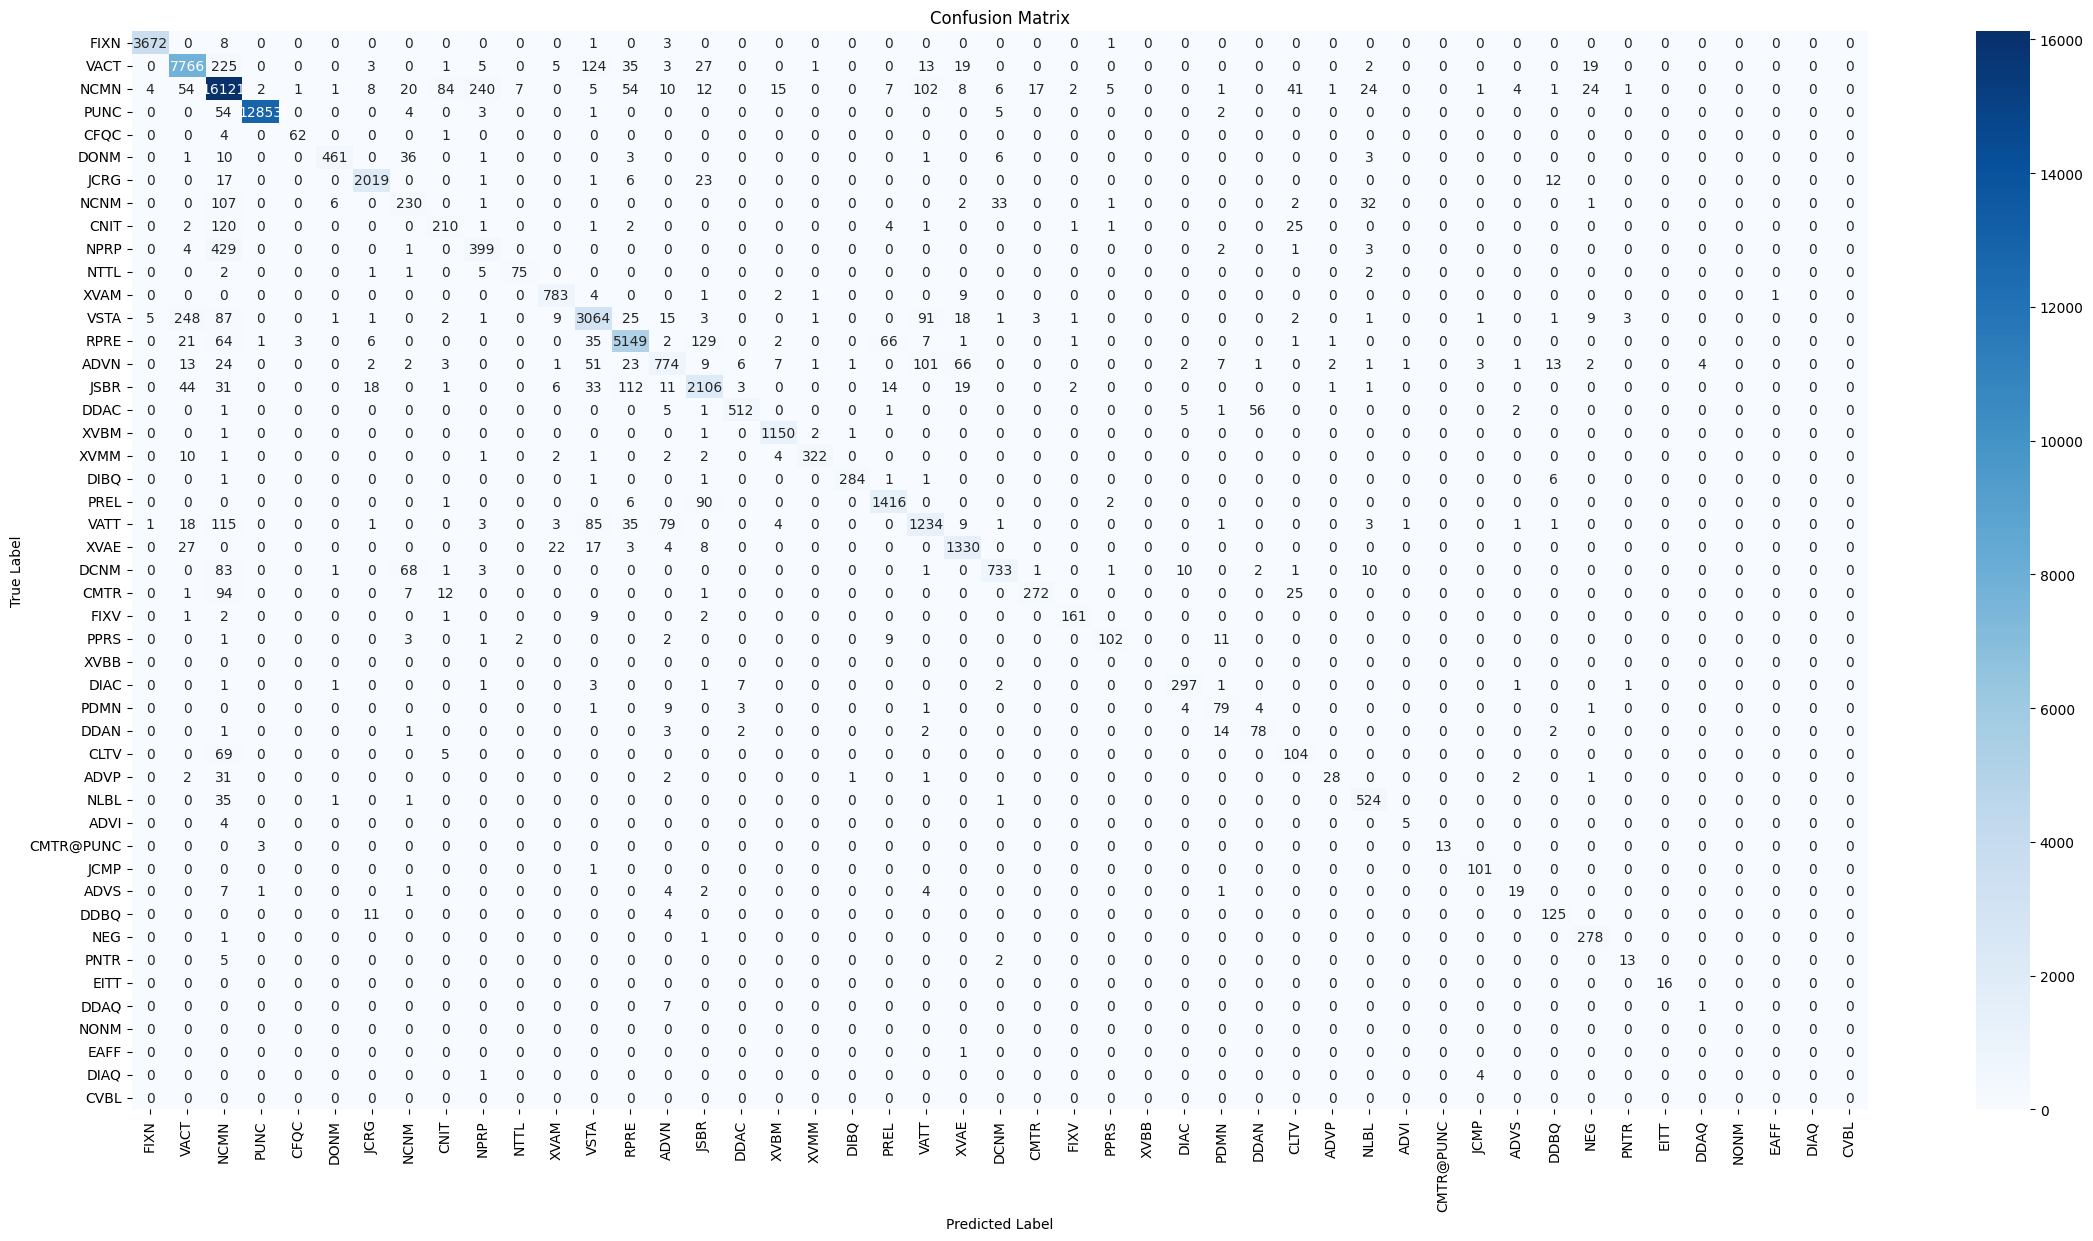

In [ ]:
# Confusion matrix of No pretrain weight model
y_pred_CRF_trimmed = [pred[:len(true)] for true, pred in zip(y_test, y_pred_CRF)]
plot_confusion_matrix(y_test, y_pred_CRF_trimmed, label_to_idx)

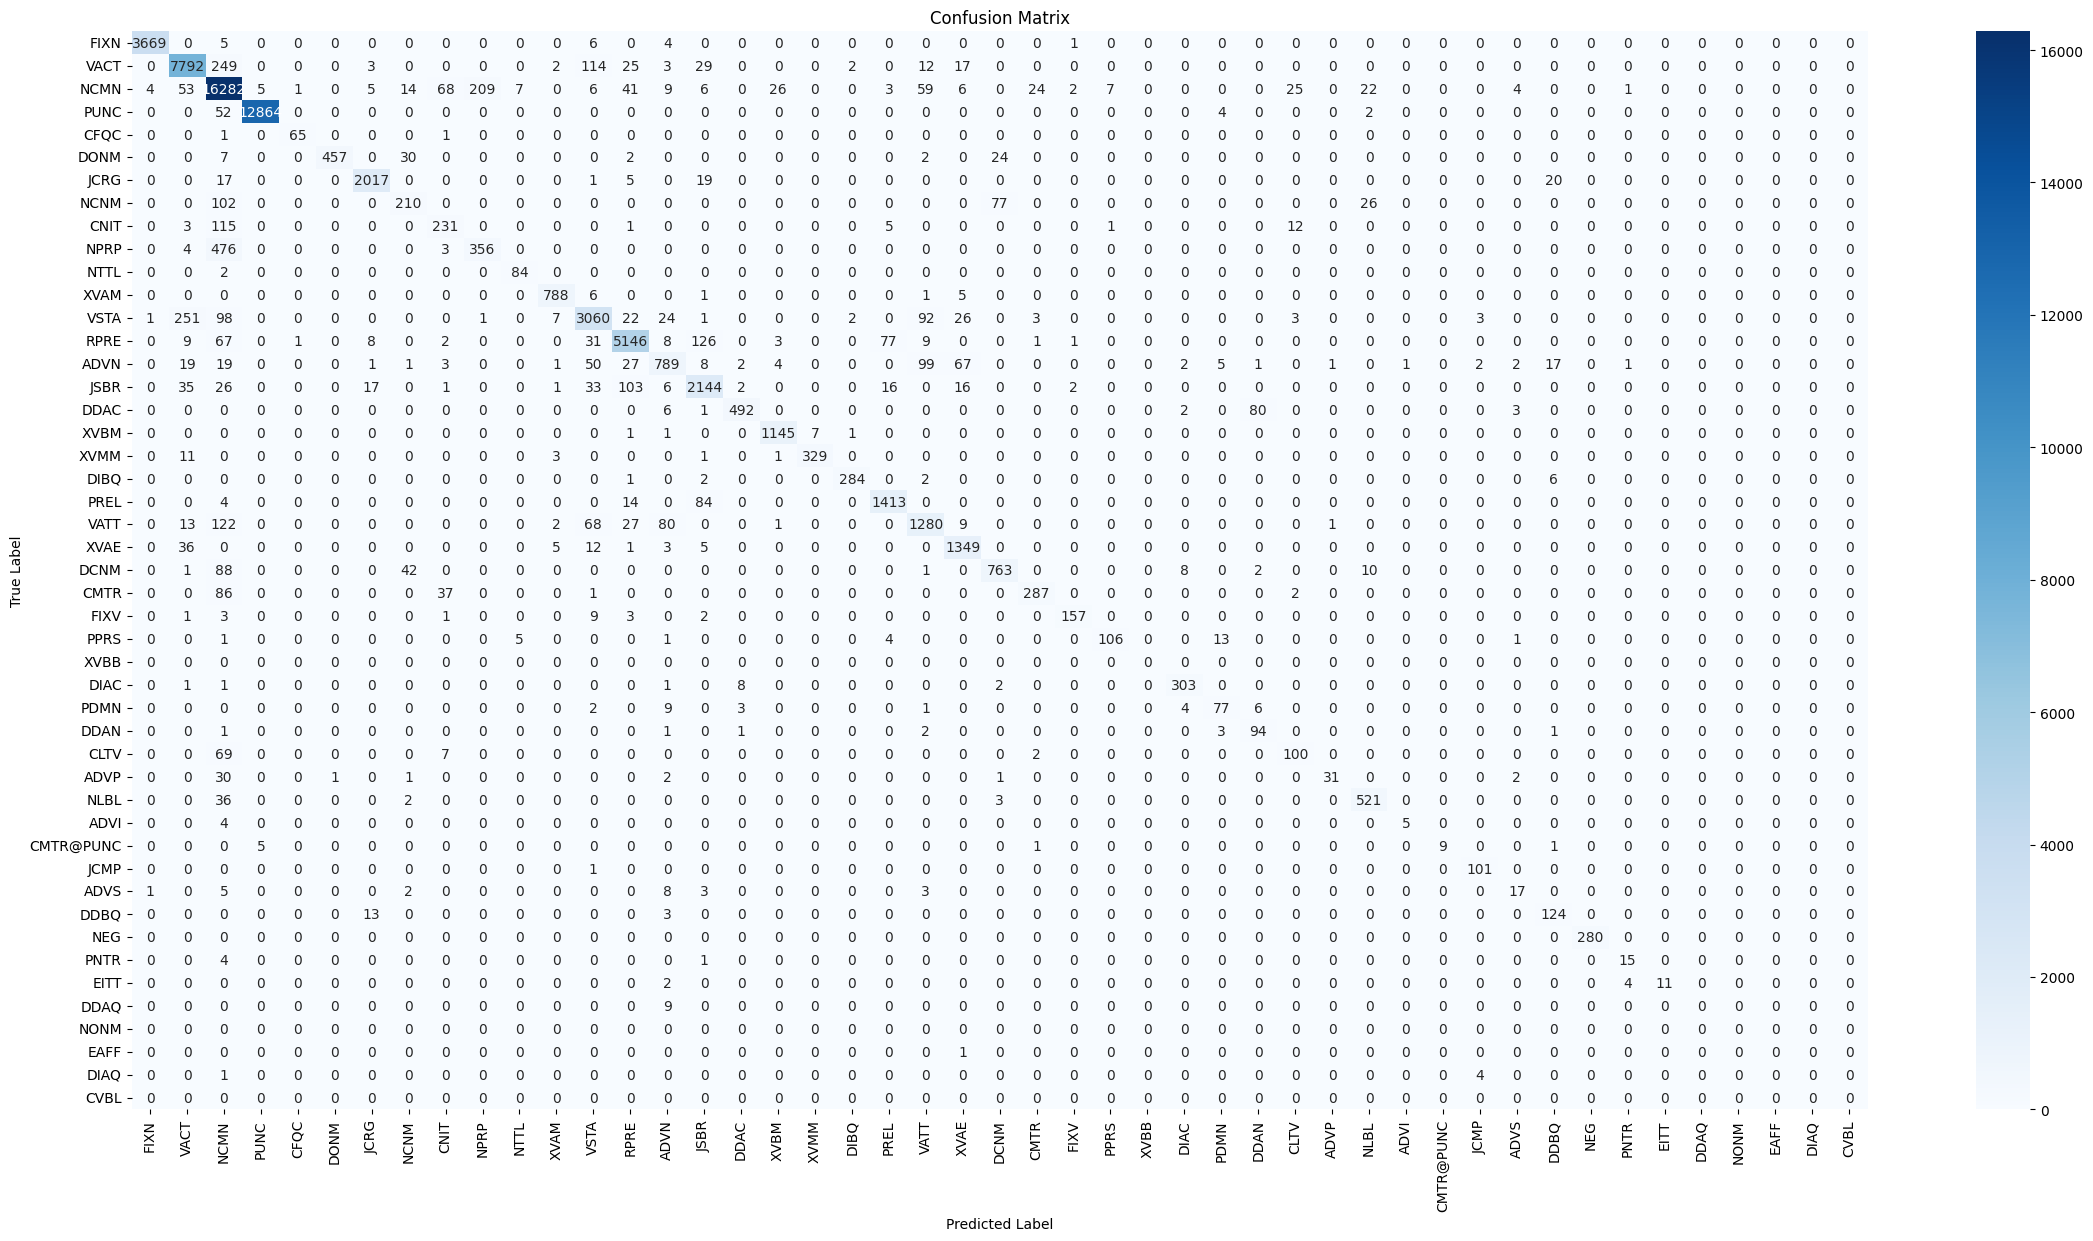

In [ ]:
# Confusion matrix of pretrain weight model
y_pred_CRF_pm_trimmed = [pred[:len(true)] for true, pred in zip(y_test, y_pred_CRF_pm)]
plot_confusion_matrix(y_test, y_pred_CRF_pm_trimmed, label_to_idx)

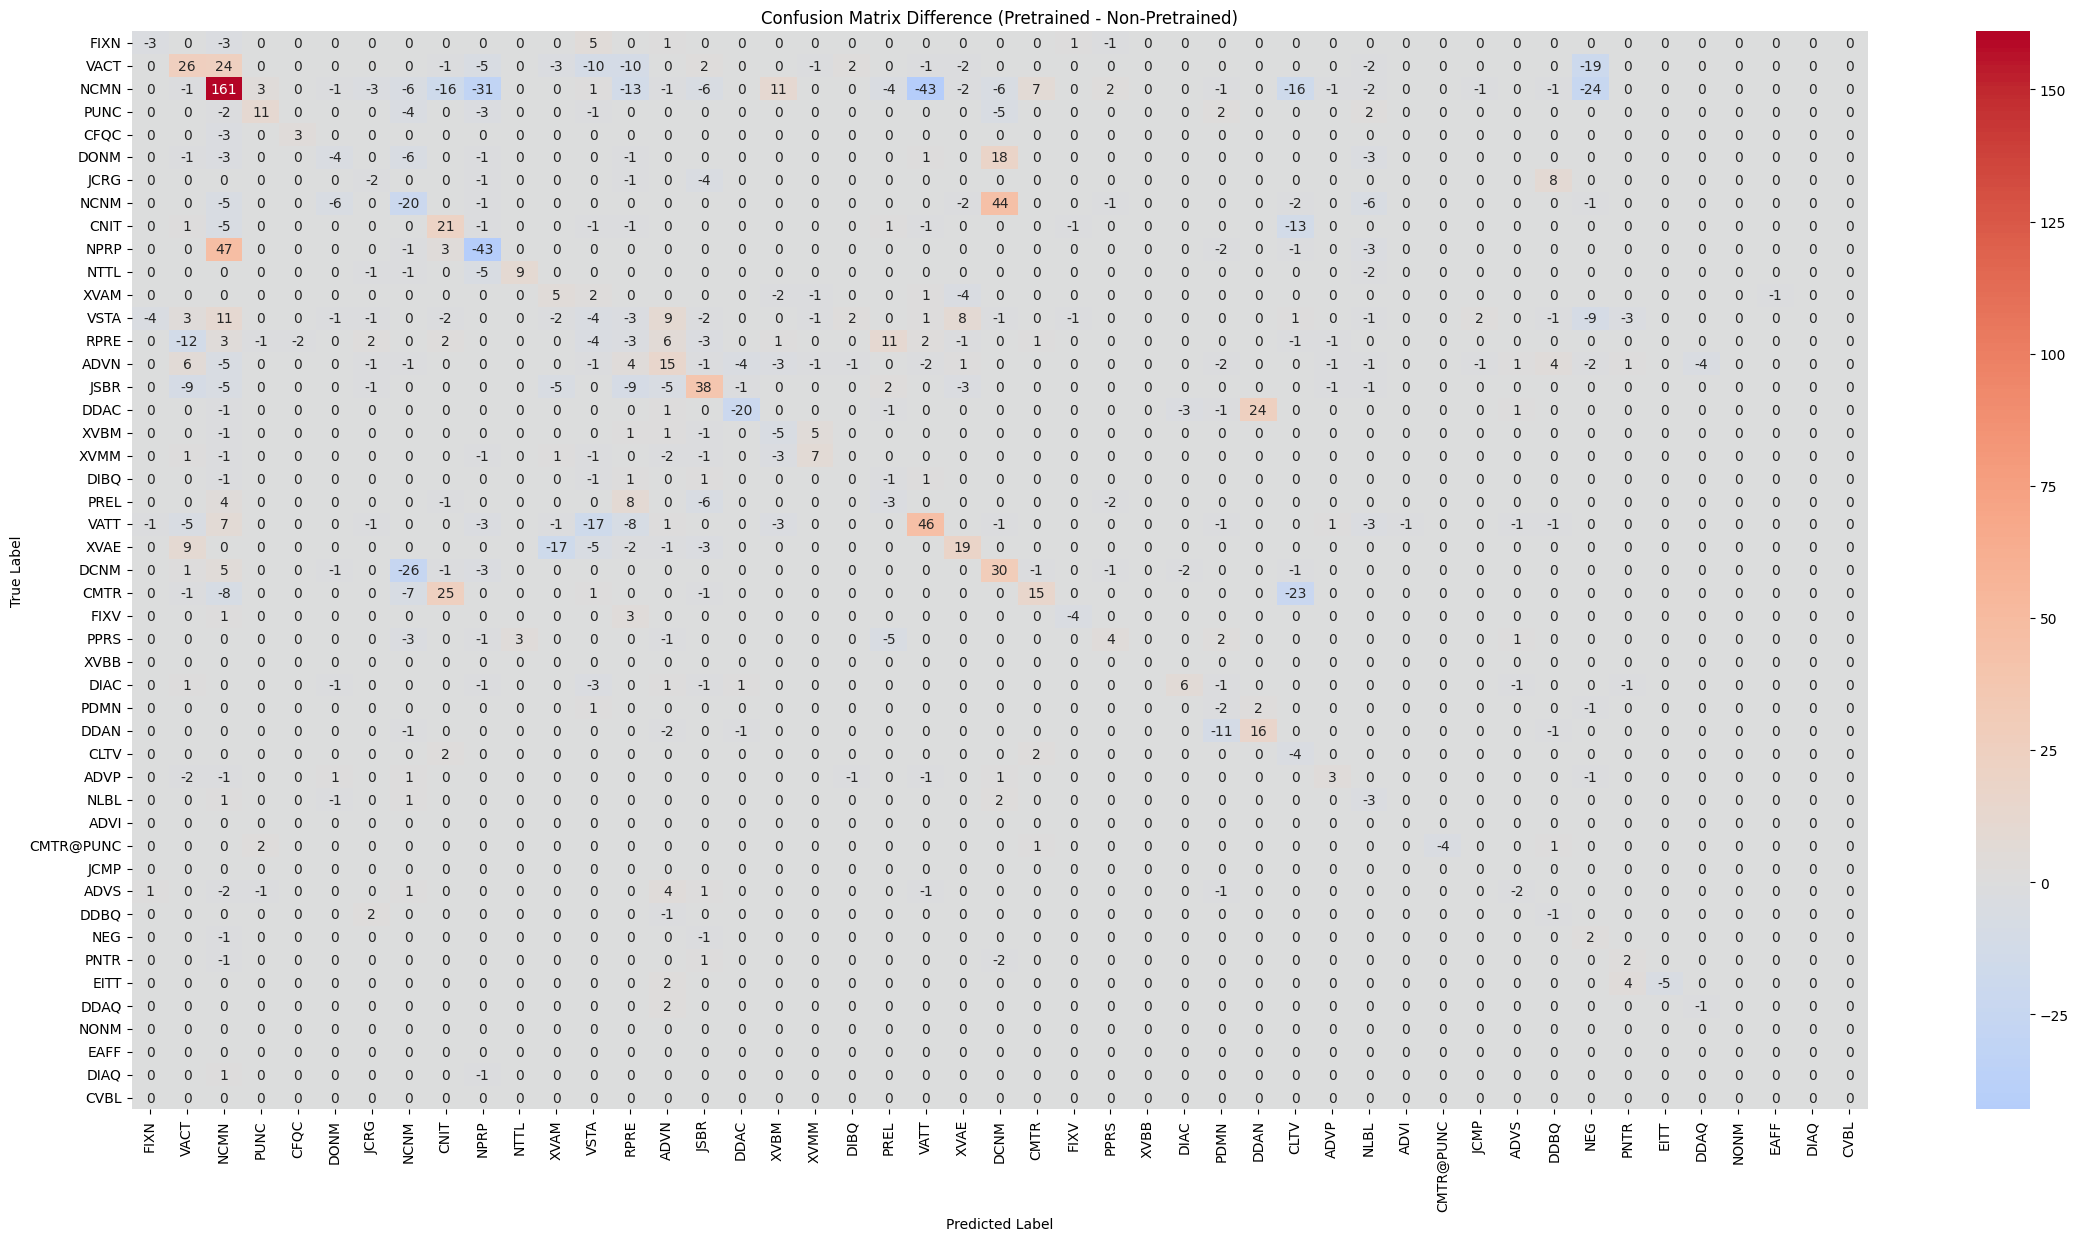

In [ ]:
# Confusion matrix of difference value of pretrained and no pretrained weight model
plot_confusion_matrix_difference(y_test, y_pred_CRF_trimmed, y_test, y_pred_CRF_pm_trimmed, label_to_idx)

In last confusion matrix is difference of `Pretrained weight model - No pretrained weight model`. To interpret we can seperate in to 3 cases, positive value(Red), near zero value(Grey) and negative value(Blue)  

- **Positive values:** indicate the pretrained weight model imporved (more correct classification)

- **Near zero values:** indicate no significant change between two models

- **Negative values:**  indicate the pretrained weight model worse (more missclassification)


Focus on the diagonal values, this diagonal element represent the correct predictions for each class

Example Interpretation:

- tag `NCMN` has more correct prediction with the pretrained weight model, this suggests significant improvement 
- tag `NPRP` has fewer correct prediction, the pretrained weight model performed worse for this class

**Overall summarize**

Pretrained weight can improve for reduce time for training that mean in the large data or bigger model, pretrained weight should has more efficient for training in limit computing resources, but some are prone to overfitting when train to much or we can try to freeze weight to not update weight and use only pretrained weight may help to reduce overfitting.